# Rootzone pH/EC — 10-Minute Recursive Prediction Model

## Architecture
- **Phase 1 (XGBoost):** Predict pH/EC delta at each 10-min step. Train on linearly interpolated labels between real measurements.
- **Phase 2 (Recursive evaluation):** Anchor at real labeled point → predict forward 10 min at a time feeding predictions back as inputs → measure error at next real labeled point.
- **Phase 3 (LSTM):** If XGBoost recursive error compounds too fast, replace with 2-layer LSTM with teacher forcing.

## Key design decisions
- Interpolation creates dense pseudo-labels (16k rows) from sparse real measurements (109 points)
- Walk-forward: never use future real labels during training
- Evaluation only on real labeled points — never on interpolated pseudo-labels
- Error compounding diagnostic: plot MAE vs steps-ahead to decide XGBoost vs LSTM


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. Data Loading
# ==========================================
df = pd.read_csv("master.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").set_index("timestamp")
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")
master_df = df.copy().sort_index()

# Full 10-min grid
full_idx = master_df.index
n_rows   = len(full_idx)

# Real labeled points (joint pH + EC)
labeled_mask = master_df["ph"].notna() & master_df["ec_ms"].notna()
labeled_idx  = master_df.index[labeled_mask]
n_labeled    = int(labeled_mask.sum())

print(f"Total 10-min rows : {n_rows}")
print(f"Labeled points    : {n_labeled}")
print(f"Sparsity          : 1 label per {n_rows/n_labeled:.0f} rows on average")
print(f"Date range        : {full_idx[0]} → {full_idx[-1]}")

ACID_FERTS = ["Phosphoric acid[mg]-H3PO4"]
SALT_FERTS = ["Monopotassium Phosphate[mg] -KH2PO4", "Potassium Chloride[mg] - KCL",
              "Kortin [mg]", "Ammonium Nitrate [mg] -NH4NO3", "Gypsum - CaSO4*2H2O [mg]"]

def _to_num(s, d=0.0): return pd.to_numeric(s, errors="coerce").fillna(d)


Total 10-min rows : 16682
Labeled points    : 109
Sparsity          : 1 label per 153 rows on average
Date range        : 2025-05-29 01:00:00 → 2025-09-21 21:10:00


Interpolated targets: pH=14567 rows, EC=14567 rows
Real labels kept as-is: pH=109, EC=109


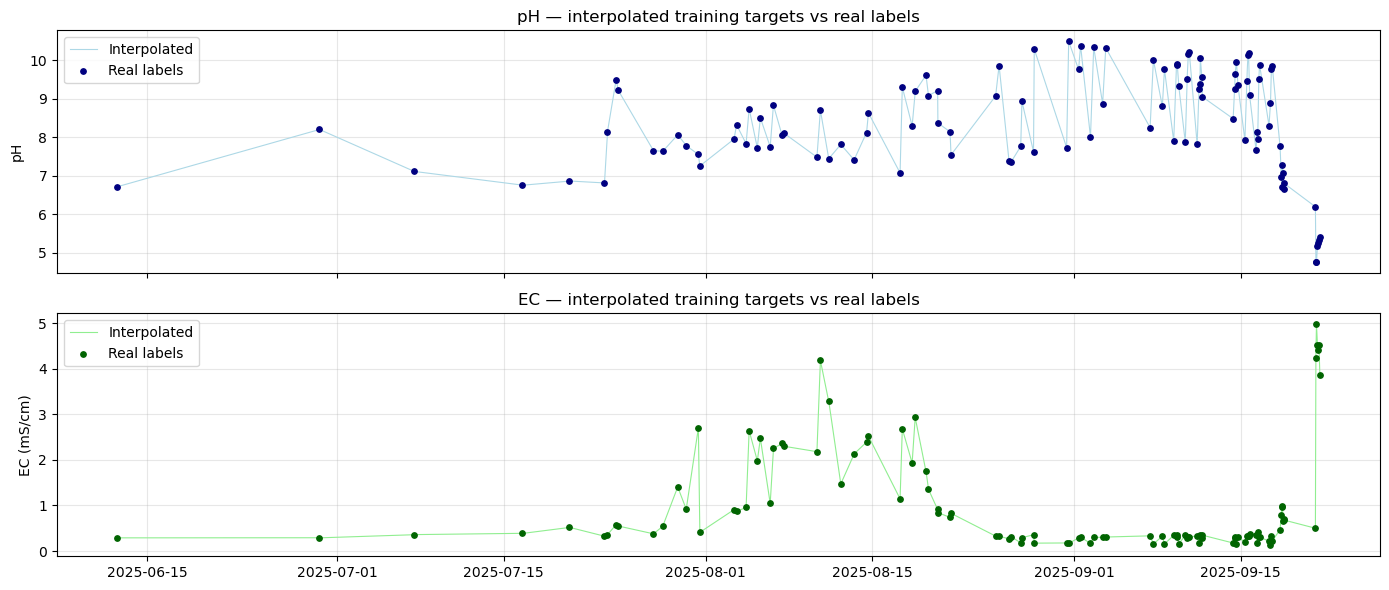

In [2]:
# ==========================================
# 2. Create Dense Pseudo-Labels via Linear Interpolation
# ==========================================
# Linear interpolation between consecutive real labeled points.
# Interpolation is ONLY within segments bounded by two real labels —
# we never extrapolate beyond the last known real value.
# Pseudo-labels are used for TRAINING only — evaluation uses real labels only.

def build_interpolated_targets(master_df, labeled_idx):
    """
    Returns a Series for ph and ec_ms, filled by linear interpolation
    between consecutive labeled points. Rows outside labeled segments
    (before first label or after last label) are NaN and excluded from training.
    """
    ph_interp  = master_df["ph"].copy()
    ec_interp  = master_df["ec_ms"].copy()

    # Forward-fill then back-fill within labeled segments only
    # Use pandas interpolate with limit_area="inside" to prevent extrapolation
    ph_interp  = ph_interp.interpolate(method="time", limit_area="inside")
    ec_interp  = ec_interp.interpolate(method="time", limit_area="inside")

    n_ph = ph_interp.notna().sum()
    n_ec = ec_interp.notna().sum()
    print(f"Interpolated targets: pH={n_ph} rows, EC={n_ec} rows")
    print(f"Real labels kept as-is: pH={master_df['ph'].notna().sum()}, EC={master_df['ec_ms'].notna().sum()}")
    return ph_interp, ec_interp

ph_interp, ec_interp = build_interpolated_targets(master_df, labeled_idx)

# Attach to a working dataframe
work_df = master_df.copy()
work_df["ph_target"]  = ph_interp
work_df["ec_target"]  = ec_interp
work_df["is_real"]    = labeled_mask.astype(int)   # 1 = real label, 0 = pseudo-label

# Verify interpolation quality visually
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(work_df.index, work_df["ph_target"],  lw=0.8, color="lightblue",  label="Interpolated")
axes[0].scatter(labeled_idx, master_df.loc[labeled_idx, "ph"],
                color="navy", s=15, zorder=5, label="Real labels")
axes[0].set_ylabel("pH"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_title("pH — interpolated training targets vs real labels")

axes[1].plot(work_df.index, work_df["ec_target"],  lw=0.8, color="lightgreen", label="Interpolated")
axes[1].scatter(labeled_idx, master_df.loc[labeled_idx, "ec_ms"],
                color="darkgreen", s=15, zorder=5, label="Real labels")
axes[1].set_ylabel("EC (mS/cm)"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_title("EC — interpolated training targets vs real labels")
plt.tight_layout(); plt.show()


In [3]:
# ==========================================
# 3. Feature Engineering — 10-Minute Step Features
# ==========================================
# At each 10-min step we use:
#   - Current state: ph_prev, ec_prev (from previous step — predicted or real)
#   - Instantaneous environment: ET0, temp, radiation, RH, irrigation, fertilization
#   - Rolling context: 6h rolling ET0, irrigation (captures session dynamics)
#   - Time encoding: hour_sin, hour_cos (cyclic)
#   - Canopy: slow-changing, captures photosynthetic capacity

def build_step_features(work_df):
    """Build the full feature matrix at 10-min resolution.
    ph_prev / ec_prev are the PREVIOUS step's target values —
    during training these are interpolated; during recursive inference they are predicted.
    """
    df = work_df.copy()

    # ── Instantaneous environment ─────────────────────────────────────────────
    df["ET0_inst"]   = _to_num(df["ET0"])          if "ET0"                  in df.columns else 0.0
    df["temp_inst"]  = _to_num(df["internal_air_temp_c"]) if "internal_air_temp_c" in df.columns else 0.0
    df["rad_inst"]   = _to_num(df["internal_radiation"])  if "internal_radiation"  in df.columns else 0.0
    df["rh_inst"]    = _to_num(df["internal_rh_%"])       if "internal_rh_%"       in df.columns else 0.0
    df["irr_inst"]   = _to_num(df["irrigation_ml_current"]) if "irrigation_ml_current" in df.columns else 0.0
    df["canopy_inst"] = _to_num(df["canopy_cover"])        if "canopy_cover"          in df.columns else 0.0

    # VPD instantaneous
    ess = 0.6108 * np.exp((17.27 * df["temp_inst"]) / (df["temp_inst"] + 237.3))
    df["vpd_inst"] = ess * (1.0 - df["rh_inst"] / 100.0)

    # Fertilization flags
    ACID_COL = "Phosphoric acid[mg]-H3PO4"
    NH4_COL  = "Ammonium Nitrate [mg] -NH4NO3"
    df["acid_inst"] = _to_num(df[ACID_COL]) if ACID_COL in df.columns else 0.0
    df["nh4_inst"]  = _to_num(df[NH4_COL])  if NH4_COL  in df.columns else 0.0
    df["salt_inst"] = sum(_to_num(df[c]) for c in SALT_FERTS if c in df.columns)

    # ── Rolling context (6h = 36 steps of 10 min) ────────────────────────────
    W6 = 36
    df["roll_ET0_6h"]  = df["ET0_inst"].rolling(W6, min_periods=1).sum()
    df["roll_irr_6h"]  = df["irr_inst"].rolling(W6, min_periods=1).sum()
    df["roll_acid_6h"] = df["acid_inst"].rolling(W6, min_periods=1).sum()
    df["roll_rad_6h"]  = df["rad_inst"].rolling(W6, min_periods=1).mean()
    df["roll_temp_6h"] = df["temp_inst"].rolling(W6, min_periods=1).mean()
    df["roll_vpd_6h"]  = df["vpd_inst"].rolling(W6, min_periods=1).mean()

    # 1h rolling for faster dynamics (6 steps)
    W1 = 6
    df["roll_irr_1h"]  = df["irr_inst"].rolling(W1, min_periods=1).sum()
    df["roll_acid_1h"] = df["acid_inst"].rolling(W1, min_periods=1).sum()

    # ── Time encoding ──────────────────────────────────────────────────────────
    hour_frac = df.index.hour + df.index.minute / 60.0
    df["hour_sin"] = np.sin(2 * np.pi * hour_frac / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * hour_frac / 24.0)

    # ── Previous-step state (shift by 1 step = 10 min) ────────────────────────
    # These are filled from interpolated targets during training.
    # During recursive inference they are replaced with model predictions.
    df["ph_prev"] = df["ph_target"].shift(1)
    df["ec_prev"] = df["ec_target"].shift(1)

    return df

print("Building step features...")
feat_df = build_step_features(work_df)

STEP_FEATURES = [
    # Current state
    "ph_prev", "ec_prev",
    # Instantaneous environment
    "ET0_inst", "temp_inst", "rad_inst", "rh_inst",
    "vpd_inst", "irr_inst", "canopy_inst",
    "acid_inst", "nh4_inst", "salt_inst",
    # Rolling context 6h
    "roll_ET0_6h", "roll_irr_6h", "roll_acid_6h",
    "roll_rad_6h", "roll_temp_6h", "roll_vpd_6h",
    # Rolling context 1h
    "roll_irr_1h", "roll_acid_1h",
    # Time encoding
    "hour_sin", "hour_cos",
]

print(f"Step features: {len(STEP_FEATURES)}")
print(f"Training rows available: {feat_df[['ph_target','ec_target']].dropna().shape[0]}")


Building step features...
Step features: 22
Training rows available: 14567


In [4]:
# ==========================================
# 4. Walk-Forward Training — 10-Minute XGBoost
# ==========================================
# Walk-forward protocol:
#   - Warmup: use rows up to the Nth real labeled point to build initial training set
#   - At each real labeled point: retrain on all data seen so far
#   - Evaluation: only at real labeled points (not pseudo-labels)
#
# Training targets: ph_delta = ph_target(t) - ph_prev(t) per step
# This keeps the model predicting incremental changes, not absolute values.

XGB_PH_PARAMS = {
    "n_estimators": 400,
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "reg_alpha": 0.5,
    "reg_lambda": 1.5,
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist",
}

XGB_EC_PARAMS = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_child_weight": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "reg_alpha": 0.3,
    "reg_lambda": 1.5,
    "random_state": 42,
    "n_jobs": -1,
    "objective": "reg:pseudohubererror",
    "huber_slope": 0.1,
}

WARMUP_LABELS = 40   # number of real labeled points to use for initial warmup

def run_10min_walkforward(feat_df, labeled_idx, warmup_labels=WARMUP_LABELS):
    """
    Walk-forward at 10-min resolution.
    Returns per-real-label evaluation results.
    """
    # Drop rows with no features or no target
    valid_mask = (
        feat_df[STEP_FEATURES].notna().all(axis=1) &
        feat_df["ph_target"].notna() &
        feat_df["ec_target"].notna()
    )
    vdf = feat_df[valid_mask].copy()

    # Targets: delta per 10-min step
    vdf["dph_step"] = vdf["ph_target"] - vdf["ph_prev"]
    vdf["dec_step"] = vdf["ec_target"] - vdf["ec_prev"]
    vdf = vdf.dropna(subset=["dph_step", "dec_step"])

    # Warmup: all rows up to warmup_labels-th real label
    warmup_cutoff = labeled_idx[warmup_labels - 1]
    train_mask = vdf.index <= warmup_cutoff

    train_df  = vdf[train_mask].copy()
    print(f"Warmup training rows: {len(train_df)}")
    print(f"  (up to {warmup_cutoff}, covering {warmup_labels} real labels)")

    ph_model = xgb.XGBRegressor(**XGB_PH_PARAMS)
    ec_model = xgb.XGBRegressor(**XGB_EC_PARAMS)
    ph_model.fit(train_df[STEP_FEATURES], train_df["dph_step"], verbose=False)
    ec_model.fit(train_df[STEP_FEATURES], train_df["dec_step"], verbose=False)

    results     = []
    retrain_count = 0
    eval_labels = labeled_idx[warmup_labels:]  # labels we evaluate on

    for label_ts in eval_labels:
        # Find the previous real label (anchor)
        pos = list(labeled_idx).index(label_ts)
        anchor_ts = labeled_idx[pos - 1]

        # Get rows in (anchor_ts, label_ts] from feat_df
        segment = feat_df.loc[(feat_df.index > anchor_ts) & (feat_df.index <= label_ts)].copy()
        if len(segment) == 0:
            continue

        # ── Recursive prediction from anchor ──────────────────────────────────
        ph_running = float(master_df.loc[anchor_ts, "ph"])
        ec_running = float(master_df.loc[anchor_ts, "ec_ms"])

        ph_preds, ec_preds, steps = [], [], []
        for step_ts, row in segment.iterrows():
            # Build feature vector — replace ph_prev/ec_prev with running prediction
            feat_vec = row[STEP_FEATURES].copy()
            feat_vec["ph_prev"] = ph_running
            feat_vec["ec_prev"] = ec_running

            if feat_vec.isna().any():
                # Skip steps with missing environment data — carry forward
                ph_preds.append(ph_running)
                ec_preds.append(ec_running)
                steps.append(step_ts)
                continue

            dph = float(ph_model.predict(pd.DataFrame([feat_vec])[STEP_FEATURES])[0])
            dec = float(ec_model.predict(pd.DataFrame([feat_vec])[STEP_FEATURES])[0])
            ph_running = ph_running + dph
            ec_running = max(0.0, ec_running + dec)

            ph_preds.append(ph_running)
            ec_preds.append(ec_running)
            steps.append(step_ts)

        # Final prediction is the last step = label_ts
        ph_final = ph_preds[-1]
        ec_final = ec_preds[-1]
        ph_true  = float(master_df.loc[label_ts, "ph"])
        ec_true  = float(master_df.loc[label_ts, "ec_ms"])
        ph_anchor = float(master_df.loc[anchor_ts, "ph"])
        ec_anchor = float(master_df.loc[anchor_ts, "ec_ms"])
        gap_h = (label_ts - anchor_ts).total_seconds() / 3600.0
        n_steps = len(steps)

        results.append({
            "timestamp":  label_ts,
            "gap_hours":  gap_h,
            "n_steps":    n_steps,
            "ph_pred":    ph_final,
            "ec_pred":    ec_final,
            "ph_true":    ph_true,
            "ec_true":    ec_true,
            "ph_naive":   ph_anchor,
            "ec_naive":   ec_anchor,
            "ph_ae":      abs(ph_final - ph_true),
            "ec_ae":      abs(ec_final - ec_true),
            "ph_ae_naive": abs(ph_anchor - ph_true),
            "ec_ae_naive": abs(ec_anchor - ec_true),
            # Store intermediate predictions for error compounding analysis
            "_ph_preds":  ph_preds,
            "_ec_preds":  ec_preds,
            "_steps":     steps,
        })

        # Retrain: add all rows in this segment to training
        new_rows = vdf.loc[(vdf.index > anchor_ts) & (vdf.index <= label_ts)]
        if len(new_rows) > 0:
            train_df  = pd.concat([train_df, new_rows]).sort_index()
            ph_model.fit(train_df[STEP_FEATURES], train_df["dph_step"], verbose=False)
            ec_model.fit(train_df[STEP_FEATURES], train_df["dec_step"], verbose=False)
            retrain_count += 1

    eval_df = pd.DataFrame(results).set_index("timestamp")
    return eval_df, ph_model, ec_model, retrain_count

print("Running 10-min walk-forward XGBoost...")
eval_df, ph_model_10, ec_model_10, n_retrains = run_10min_walkforward(feat_df, list(labeled_idx))

ph_mae = eval_df["ph_ae"].mean()
ec_mae = eval_df["ec_ae"].mean()
ph_r2  = r2_score(eval_df["ph_true"], eval_df["ph_pred"])
ec_r2  = r2_score(eval_df["ec_true"], eval_df["ec_pred"])
ph_naive_mae = eval_df["ph_ae_naive"].mean()
ec_naive_mae = eval_df["ec_ae_naive"].mean()

print(f"\n{'='*50}")
print(f"10-min XGBoost Recursive Results")
print(f"{'='*50}")
print(f"pH  MAE={ph_mae:.4f}  naive={ph_naive_mae:.4f}  gain={ph_naive_mae-ph_mae:.4f}  R²={ph_r2:.4f}")
print(f"EC  MAE={ec_mae:.4f}  naive={ec_naive_mae:.4f}  gain={ec_naive_mae-ec_mae:.4f}  R²={ec_r2:.4f}")
print(f"Retrains: {n_retrains} | Eval points: {len(eval_df)}")
print(f"\nV3 XGBoost baseline: pH MAE=0.4187  EC MAE=0.1763")


Running 10-min walk-forward XGBoost...
Warmup training rows: 9939
  (up to 2025-08-20 12:20:00, covering 40 real labels)

10-min XGBoost Recursive Results
pH  MAE=1.3019  naive=0.9743  gain=-0.3275  R²=-5.7671
EC  MAE=0.2170  naive=0.1829  gain=-0.0341  R²=0.8036
Retrains: 69 | Eval points: 69

V3 XGBoost baseline: pH MAE=0.4187  EC MAE=0.1763


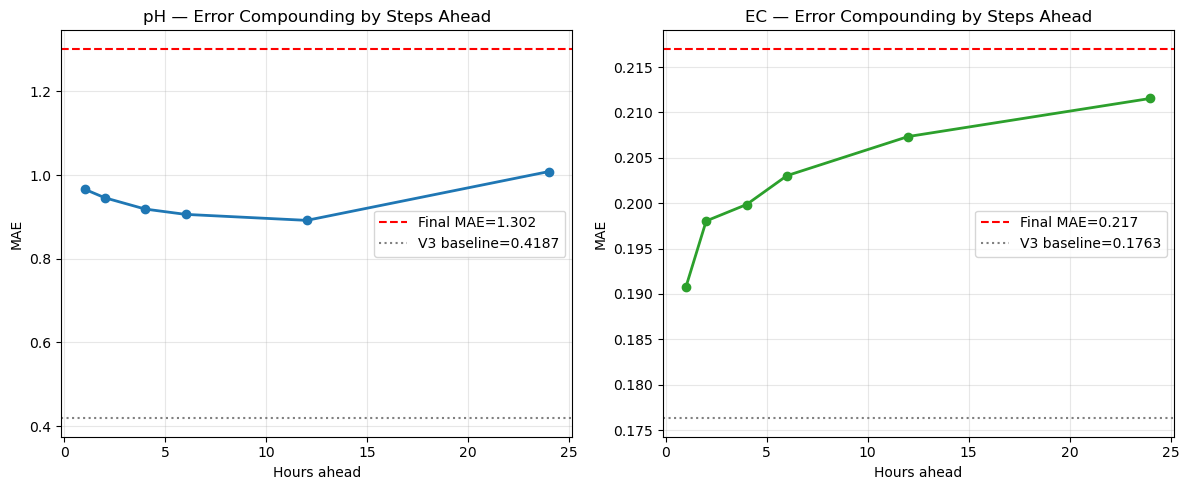


=== ERROR COMPOUNDING VERDICT ===
pH  MAE ratio (last/first bin): 1.04x
EC  MAE ratio (last/first bin): 1.11x

pH: Error growth is ACCEPTABLE — XGBoost recursive is viable.
EC: Error growth is ACCEPTABLE — XGBoost recursive is viable.


In [5]:
# ==========================================
# 5. Error Compounding Diagnostic
# ==========================================
# For each evaluation segment, compute MAE at 1h, 2h, 4h, 6h, 12h, 24h steps ahead.
# If error grows slowly -> XGBoost is viable for recursive use.
# If error doubles within 2h -> need LSTM.

step_minutes = 10
bins_hours   = [1, 2, 4, 6, 12, 24]
bins_steps   = [int(h * 60 / step_minutes) for h in bins_hours]

ph_mae_by_steps, ec_mae_by_steps = {b: [] for b in bins_hours}, {b: [] for b in bins_hours}

for _, row in eval_df.iterrows():
    phs  = row["_ph_preds"]
    ecs  = row["_ec_preds"]
    stps = row["_steps"]
    ph_t = row["ph_true"]
    ec_t = row["ec_true"]

    if len(phs) == 0:
        continue

    # The anchor values
    anchor_ph = row["ph_naive"]
    anchor_ec = row["ec_naive"]

    for h, s in zip(bins_hours, bins_steps):
        # Find prediction at approximately h hours ahead
        idx = min(s - 1, len(phs) - 1)
        ph_mae_by_steps[h].append(abs(phs[idx] - ph_t))
        ec_mae_by_steps[h].append(abs(ecs[idx] - ec_t))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ph_means = [np.mean(ph_mae_by_steps[h]) for h in bins_hours if ph_mae_by_steps[h]]
ec_means = [np.mean(ec_mae_by_steps[h]) for h in bins_hours if ec_mae_by_steps[h]]
valid_hours_ph = [h for h in bins_hours if ph_mae_by_steps[h]]
valid_hours_ec = [h for h in bins_hours if ec_mae_by_steps[h]]

axes[0].plot(valid_hours_ph, ph_means, "o-", color="tab:blue", lw=2)
axes[0].axhline(ph_mae, color="red", ls="--", label=f"Final MAE={ph_mae:.3f}")
axes[0].axhline(0.4187, color="gray", ls=":", label="V3 baseline=0.4187")
axes[0].set_xlabel("Hours ahead"); axes[0].set_ylabel("MAE")
axes[0].set_title("pH — Error Compounding by Steps Ahead")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(valid_hours_ec, ec_means, "o-", color="tab:green", lw=2)
axes[1].axhline(ec_mae, color="red", ls="--", label=f"Final MAE={ec_mae:.3f}")
axes[1].axhline(0.1763, color="gray", ls=":", label="V3 baseline=0.1763")
axes[1].set_xlabel("Hours ahead"); axes[1].set_ylabel("MAE")
axes[1].set_title("EC — Error Compounding by Steps Ahead")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Verdict
print("\n=== ERROR COMPOUNDING VERDICT ===")
if len(ph_means) >= 2:
    ratio_ph = ph_means[-1] / (ph_means[0] + 1e-9)
    ratio_ec = ec_means[-1] / (ec_means[0] + 1e-9) if ec_means else 0
    print(f"pH  MAE ratio (last/first bin): {ratio_ph:.2f}x")
    print(f"EC  MAE ratio (last/first bin): {ratio_ec:.2f}x")
    print()
    if ratio_ph < 3.0:
        print("pH: Error growth is ACCEPTABLE — XGBoost recursive is viable.")
    else:
        print("pH: Error growth is HIGH — consider LSTM for better long-range stability.")
    if ratio_ec < 3.0:
        print("EC: Error growth is ACCEPTABLE — XGBoost recursive is viable.")
    else:
        print("EC: Error growth is HIGH — consider LSTM for better long-range stability.")


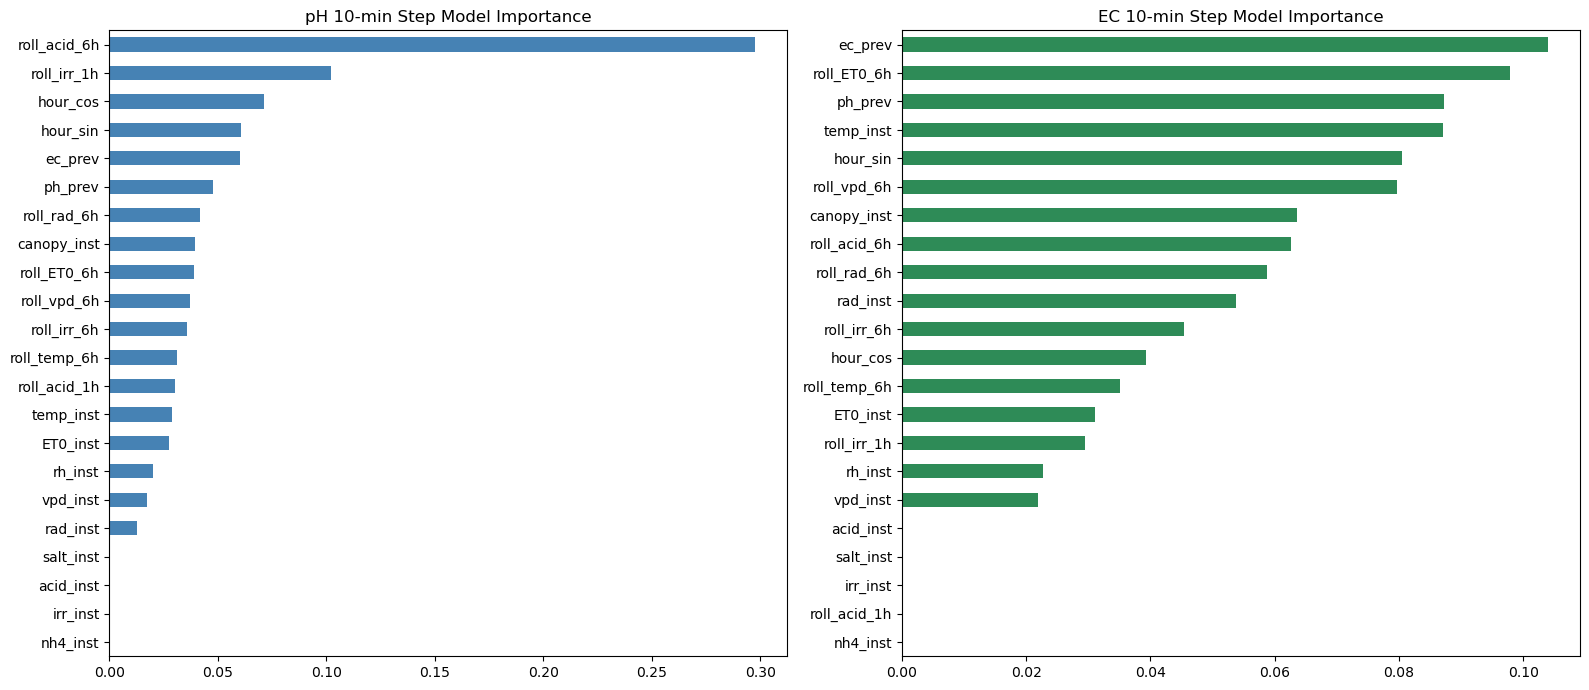

In [6]:
# ==========================================
# 6. Feature Importance — 10-Minute Model
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

pd.Series(ph_model_10.feature_importances_, index=STEP_FEATURES)    .sort_values()    .plot(kind="barh", ax=axes[0], title="pH 10-min Step Model Importance", color="steelblue")

pd.Series(ec_model_10.feature_importances_, index=STEP_FEATURES)    .sort_values()    .plot(kind="barh", ax=axes[1], title="EC 10-min Step Model Importance", color="seagreen")

plt.tight_layout(); plt.show()


pH gap-bin report:


,n,ph_mae,ph_naive
gap_bin,,,
0-12h,49,0.6269,0.7633
12-24h,14,1.2416,1.5900
24h+,6,6.9548,1.2617



EC gap-bin report:


,n,ec_mae,ec_naive
gap_bin,,,
0-12h,49,0.2289,0.2052
12-24h,14,0.1478,0.1124
24h+,6,0.2816,0.1652


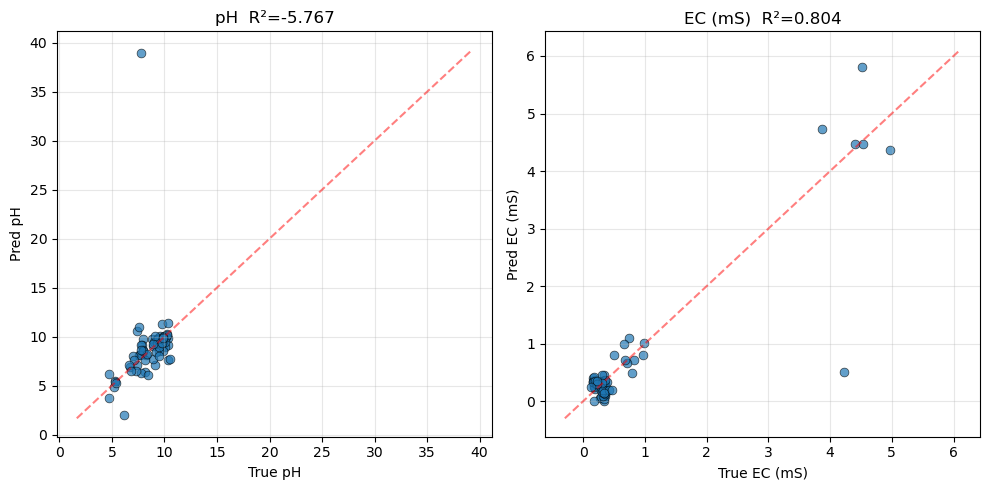

In [7]:
# ==========================================
# 7. Gap-Bin Report + Scatter
# ==========================================
eval_df["gap_bin"] = pd.cut(eval_df["gap_hours"], [-np.inf, 12, 24, np.inf],
                             labels=["0-12h", "12-24h", "24h+"])

print("pH gap-bin report:")
ph_gb = eval_df.groupby("gap_bin", observed=False).agg(
    n=("ph_ae", "count"),
    ph_mae=("ph_ae", "mean"),
    ph_naive=("ph_ae_naive", "mean")).round(4)
display(ph_gb)

print("\nEC gap-bin report:")
ec_gb = eval_df.groupby("gap_bin", observed=False).agg(
    n=("ec_ae", "count"),
    ec_mae=("ec_ae", "mean"),
    ec_naive=("ec_ae_naive", "mean")).round(4)
display(ec_gb)

# Scatter
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, tc, pc, name in [
    (axes[0], "ph_true", "ph_pred", "pH"),
    (axes[1], "ec_true", "ec_pred", "EC (mS)"),
]:
    t, p = eval_df[tc].values, eval_df[pc].values
    ax.scatter(t, p, alpha=0.7, s=40, edgecolors="k", lw=0.5)
    lims = [min(t.min(), p.min()) - 0.3, max(t.max(), p.max()) + 0.3]
    ax.plot(lims, lims, "r--", alpha=0.5)
    ax.set_xlabel(f"True {name}"); ax.set_ylabel(f"Pred {name}")
    ax.set_title(f"{name}  R²={r2_score(t, p):.3f}")
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [8]:
# ==========================================
# 8. Phase 3 — LSTM (run if XGBoost error compounds too fast)
# ==========================================
# Prerequisites: run cells 1-7 first.
# Only run this cell if the error compounding diagnostic in Cell 5
# shows ratio > 3x (error more than triples over the longest gaps).
#
# Architecture:
#   Input:  sequence of T=12 steps (2 hours) × N_FEATURES
#   LSTM:   2 layers, hidden_size=64, dropout=0.2
#   Output: 2 values (dph, dec) for the NEXT step
#   Loss:   Huber loss (robust to the EC spike outliers)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
SEQ_LEN   = 12       # 2 hours of context (12 × 10 min)
HIDDEN    = 64
N_LAYERS  = 2
DROPOUT   = 0.2
BATCH     = 32
EPOCHS    = 80
LR        = 3e-4
PATIENCE  = 12       # early stopping patience

print(f"Device: {DEVICE}")
print(f"Sequence length: {SEQ_LEN} steps = {SEQ_LEN * 10} minutes of context")

# ── Dataset ───────────────────────────────────────────────────────────────────
class StepDataset(Dataset):
    """
    Each sample: (X[t-SEQ_LEN:t], y[t]) where
      X[i] = STEP_FEATURES at step i
      y    = (dph, dec) for step t
    Only samples where both ph_target and ec_target are available are used.
    """
    def __init__(self, feat_df, seq_len=SEQ_LEN, cutoff=None):
        df = feat_df.copy()
        if cutoff is not None:
            df = df[df.index <= cutoff]

        # Keep only rows with valid targets
        valid = df["ph_target"].notna() & df["ec_target"].notna()
        df    = df[valid].copy()
        df["dph_step"] = df["ph_target"] - df["ph_prev"]
        df["dec_step"] = df["ec_target"] - df["ec_prev"]
        df = df.dropna(subset=["dph_step", "dec_step"] + STEP_FEATURES)

        X = df[STEP_FEATURES].values.astype(np.float32)
        Y = df[["dph_step", "dec_step"]].values.astype(np.float32)
        self.X, self.Y = X, Y
        self.seq_len   = seq_len

    def __len__(self):
        return max(0, len(self.X) - self.seq_len)

    def __getitem__(self, i):
        return (torch.tensor(self.X[i:i+self.seq_len]),
                torch.tensor(self.Y[i+self.seq_len]))


class RootzoneRNN(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN, n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, n_layers,
                            batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 2)   # dph, dec
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])   # use last step hidden state


def train_lstm(feat_df, labeled_idx, warmup_labels=WARMUP_LABELS,
               epochs=EPOCHS, lr=LR, patience=PATIENCE):
    warmup_cutoff = labeled_idx[warmup_labels - 1]

    ds_train = StepDataset(feat_df, SEQ_LEN, cutoff=warmup_cutoff)
    dl_train = DataLoader(ds_train, batch_size=BATCH, shuffle=True)
    print(f"Training samples: {len(ds_train)}")

    model     = RootzoneRNN(input_size=len(STEP_FEATURES)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.HuberLoss(delta=0.5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_loss, no_improve, best_state = float("inf"), 0, None

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in dl_train:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(ds_train)
        scheduler.step(epoch_loss)

        if epoch_loss < best_loss - 1e-6:
            best_loss, no_improve = epoch_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"Early stop at epoch {epoch+1}  best_loss={best_loss:.6f}")
            break

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | loss={epoch_loss:.6f}")

    model.load_state_dict(best_state)
    return model


def run_lstm_walkforward(feat_df, labeled_idx, warmup_labels=WARMUP_LABELS):
    """Walk-forward with LSTM — retrain after each real label."""
    warmup_cutoff = labeled_idx[warmup_labels - 1]

    print("Training initial LSTM on warmup data...")
    lstm_model = train_lstm(feat_df, list(labeled_idx), warmup_labels)

    results  = []
    eval_labels = list(labeled_idx)[warmup_labels:]

    for label_ts in eval_labels:
        pos       = list(labeled_idx).index(label_ts)
        anchor_ts = labeled_idx[pos - 1]
        segment   = feat_df.loc[(feat_df.index > anchor_ts) & (feat_df.index <= label_ts)].copy()
        if len(segment) == 0:
            continue

        # ── Recursive LSTM inference ──────────────────────────────────────────
        # Seed the context window with the last SEQ_LEN steps of real data before anchor
        context_start = anchor_ts - pd.Timedelta(minutes=10 * SEQ_LEN)
        context = feat_df.loc[(feat_df.index >= context_start) &
                               (feat_df.index <= anchor_ts)].copy()
        if len(context) < SEQ_LEN:
            continue  # not enough context — skip

        # Use real values in context window
        ctx_X = context[STEP_FEATURES].values[-SEQ_LEN:].astype(np.float32)
        if np.isnan(ctx_X).any():
            continue

        ph_running = float(master_df.loc[anchor_ts, "ph"])
        ec_running = float(master_df.loc[anchor_ts, "ec_ms"])
        ph_preds, ec_preds = [], []

        lstm_model.eval()
        with torch.no_grad():
            for step_ts, row in segment.iterrows():
                feat_vec = row[STEP_FEATURES].copy().values.astype(np.float32)
                feat_vec[STEP_FEATURES.index("ph_prev")] = ph_running
                feat_vec[STEP_FEATURES.index("ec_prev")] = ec_running

                if np.isnan(feat_vec).any():
                    ph_preds.append(ph_running)
                    ec_preds.append(ec_running)
                    ctx_X = np.roll(ctx_X, -1, axis=0)
                    ctx_X[-1] = feat_vec
                    continue

                ctx_X = np.roll(ctx_X, -1, axis=0)
                ctx_X[-1] = feat_vec

                inp   = torch.tensor(ctx_X).unsqueeze(0).to(DEVICE)
                out   = lstm_model(inp).cpu().numpy()[0]
                dph, dec = float(out[0]), float(out[1])
                ph_running = ph_running + dph
                ec_running = max(0.0, ec_running + dec)
                ph_preds.append(ph_running)
                ec_preds.append(ec_running)

        if not ph_preds:
            continue

        ph_final  = ph_preds[-1]
        ec_final  = ec_preds[-1]
        ph_true   = float(master_df.loc[label_ts, "ph"])
        ec_true   = float(master_df.loc[label_ts, "ec_ms"])
        ph_anchor = float(master_df.loc[anchor_ts, "ph"])
        ec_anchor = float(master_df.loc[anchor_ts, "ec_ms"])
        gap_h     = (label_ts - anchor_ts).total_seconds() / 3600.0

        results.append({
            "timestamp": label_ts, "gap_hours": gap_h,
            "ph_pred": ph_final, "ec_pred": ec_final,
            "ph_true": ph_true,  "ec_true": ec_true,
            "ph_naive": ph_anchor, "ec_naive": ec_anchor,
            "ph_ae": abs(ph_final - ph_true), "ec_ae": abs(ec_final - ec_true),
            "ph_ae_naive": abs(ph_anchor - ph_true), "ec_ae_naive": abs(ec_anchor - ec_true),
        })

        # Retrain on new data
        new_cutoff = label_ts
        lstm_model = train_lstm(feat_df, list(labeled_idx),
                                 warmup_labels=pos + 1)

    lstm_eval = pd.DataFrame(results).set_index("timestamp")
    return lstm_eval, lstm_model


# ── RUN LSTM ──────────────────────────────────────────────────────────────────
# Uncomment to run. Only needed if XGBoost error compounding ratio > 3x (Cell 5).
#
# print("Training LSTM model...")
# lstm_eval, lstm_model = run_lstm_walkforward(feat_df, list(labeled_idx))
#
# ph_mae_lstm = lstm_eval["ph_ae"].mean()
# ec_mae_lstm = lstm_eval["ec_ae"].mean()
# print(f"LSTM pH  MAE={ph_mae_lstm:.4f}  R²={r2_score(lstm_eval.ph_true, lstm_eval.ph_pred):.4f}")
# print(f"LSTM EC  MAE={ec_mae_lstm:.4f}  R²={r2_score(lstm_eval.ec_true, lstm_eval.ec_pred):.4f}")
# print(f"XGBoost pH MAE={ph_mae:.4f} | LSTM pH MAE={ph_mae_lstm:.4f}")


Device: cpu
Sequence length: 12 steps = 120 minutes of context


In [9]:
# ==========================================
# 9. Final Summary — 10-Minute vs V3
# ==========================================
summary = pd.DataFrame([
    {"Model": "V3 XGBoost (interval)",    "pH MAE": 0.4187, "EC MAE": 0.1763,
     "pH R²": 0.850, "EC R²": 0.814, "Notes": "t0→t1 delta, anchor-based"},
    {"Model": "10-min XGBoost (recursive)", "pH MAE": round(ph_mae, 4),
     "EC MAE": round(ec_mae, 4),
     "pH R²": round(ph_r2, 3), "EC R²": round(ec_r2, 3),
     "Notes": "10-min steps, recursive, interpolated training"},
]).set_index("Model")
print(summary.to_string())


                            pH MAE  EC MAE  pH R²  EC R²                                           Notes
Model                                                                                                   
V3 XGBoost (interval)       0.4187  0.1763  0.850  0.814                       t0→t1 delta, anchor-based
10-min XGBoost (recursive)  1.3019  0.2170 -5.767  0.804  10-min steps, recursive, interpolated training
